Assignment no 7.Implement a basic multimodal system for image captioning using CLIP.

**Mount Google Drive**(as dataset is large,continuage uploading data after restating session is time consuming task,so used drive )

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Given Dataset path,Images File path and captions file path**

In [2]:
DATA_PATH = "/content/drive/MyDrive/Flickr8k"
IMAGE_PATH = DATA_PATH + "/Images"
CAPTION_PATH = DATA_PATH + "/captions.txt"


**Install required libraries**

In [3]:
!pip install torch torchvision transformers pillow tqdm
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-yu57e898
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-yu57e898
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


**Import required Libraries**

In [4]:
import os
import torch
import clip
from PIL import Image
from tqdm import tqdm


**Load CLIP Model**

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)


**Create Caption Loader (CSV)**

In [19]:
import csv

def load_captions_csv(path):
    mapping = {}

    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)

        next(reader)  # skip header: image,caption

        for row in reader:
            if len(row) < 2:
                continue

            img_name = row[0].strip()
            caption = row[1].strip()

            if img_name not in mapping:
                mapping[img_name] = []

            mapping[img_name].append(caption)

    return mapping


**Load Captions**

In [20]:
captions_dict = load_captions_csv(CAPTION_PATH)

print("Total Images:", len(captions_dict))


Total Images: 8091


**Verify Captions Loaded**

In [21]:
first_key = list(captions_dict.keys())[0]

print("Image:", first_key)
print("Captions:", captions_dict[first_key])


Image: 1000268201_693b08cb0e.jpg
Captions: ['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .', 'A little girl climbing into a wooden playhouse .', 'A little girl climbing the stairs to her playhouse .', 'A little girl in a pink dress going into a wooden cabin .']


**Test Image + Caption Pair**

Image: 1000268201_693b08cb0e.jpg
Caption: A child in a pink dress is climbing up a set of stairs in an entry way .


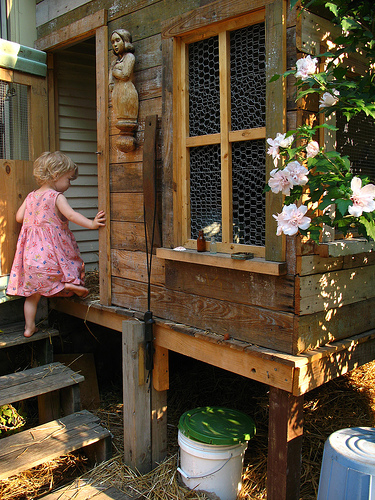

In [22]:
from PIL import Image
import os

img_name = list(captions_dict.keys())[0]

print("Image:", img_name)
print("Caption:", captions_dict[img_name][0])

img = Image.open(os.path.join(IMAGE_PATH, img_name))
img


**Convert All Captions To List**

In [28]:
all_captions = []
for caps in captions_dict.values():
    all_captions.extend(caps)

text_tokens = clip.tokenize(all_captions[:500]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)

print("Text Features Shape:", text_features.shape)

Text Features Shape: torch.Size([500, 512])


**Convert Captions → CLIP Text Features**

In [29]:
image = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    image_feature = model.encode_image(image)

print("Image Feature Shape:", image_feature.shape)


Image Feature Shape: torch.Size([1, 512])


**Extract CLIP Features For Image**

In [30]:
similarity = (image_feature @ text_features.T).softmax(dim=-1)

best_idx = similarity.argmax().item()

print("Predicted Caption:", all_captions[best_idx])


Predicted Caption: A little girl climbing the stairs to her playhouse .


**Test On Multiple Images**

In [31]:
for img_name in list(captions_dict.keys())[:5]:

    img = Image.open(os.path.join(IMAGE_PATH, img_name))

    image = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        image_feature = model.encode_image(image)

    similarity = (image_feature @ text_features.T).softmax(dim=-1)
    best_idx = similarity.argmax().item()

    print("\nImage:", img_name)
    print("Predicted Caption:", all_captions[best_idx])



Image: 1000268201_693b08cb0e.jpg
Predicted Caption: A little girl climbing the stairs to her playhouse .

Image: 1001773457_577c3a7d70.jpg
Predicted Caption: A black dog and a spotted dog are fighting

Image: 1002674143_1b742ab4b8.jpg
Predicted Caption: A child painting a picture .

Image: 1003163366_44323f5815.jpg
Predicted Caption: A shirtless man lies on a park bench with his dog .

Image: 1007129816_e794419615.jpg
Predicted Caption: A man with glasses is wearing a beer can crocheted hat .


**Show Image + Caption**

(np.float64(-0.5), np.float64(499.5), np.float64(460.5), np.float64(-0.5))

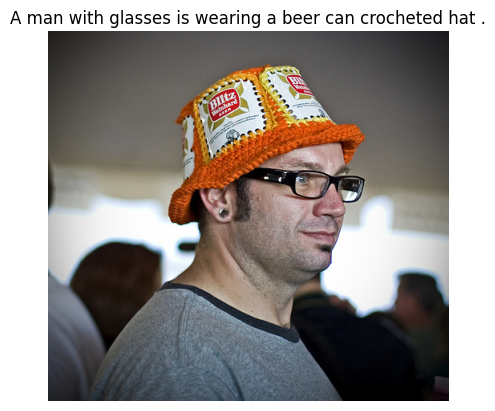

In [33]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(all_captions[best_idx])
plt.axis("off")


**Dataset → Clean captions → Make dictionary → Load CLIP → Encode captions → Encode image → Similarity → Return best caption.**